In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


RANDOM_SEED = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
DATA_DIR = r"C:\Users\patka\Downloads\Visión artificial\archive"


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

print("Clases:", train_ds.class_names)
print("Número de clases:", len(train_ds.class_names))

for x, y in train_ds.take(1):
    print("Batch imágenes:", x.shape)
    print("Batch etiquetas:", y.shape)

Found 70549 files belonging to 15 classes.
Using 56440 files for training.
Found 70549 files belonging to 15 classes.
Using 14109 files for validation.
Clases: ['Apple', 'Banana', 'Carambola', 'Guava', 'Kiwi', 'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon', 'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'muskmelon']
Número de clases: 15
Batch imágenes: (32, 224, 224, 3)
Batch etiquetas: (32, 15)


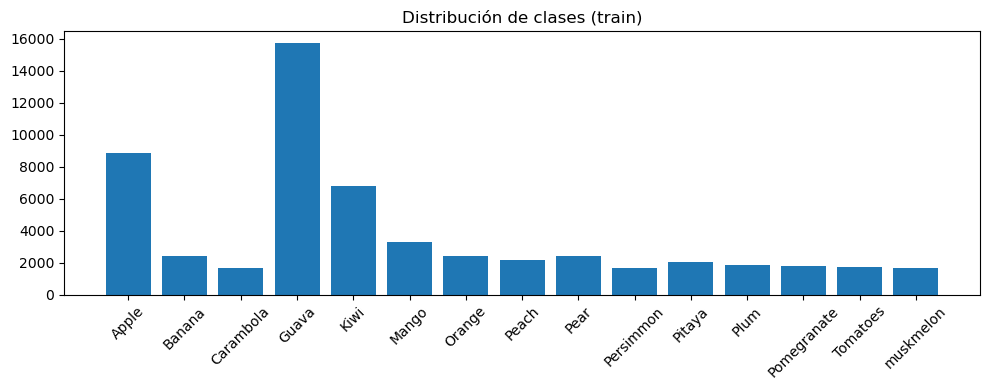

In [ ]:
from collections import Counter
class_names = train_ds.class_names

counts = {c: 0 for c in class_names}
for _, y in train_ds.unbatch():
    counts[class_names[int(np.argmax(y.numpy()))]] += 1


plt.figure(figsize=(10,4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title('Distribución de clases (train)')
plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = keras.Sequential([
layers.RandomFlip('horizontal'),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


IMG_SIZE = (224, 224)
NUM_CLASSES = len(class_names)

base_model = MobileNetV2(
input_shape=IMG_SIZE + (3,),
include_top=False,
weights='imagenet'
)
base_model.trainable = False


inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)


model = keras.Model(inputs, outputs, name='mobilenet_transfer')


model.compile(
optimizer=keras.optimizers.Adam(1e-3),
loss='categorical_crossentropy',
metrics=['accuracy']
)


model.summary()

Model: "mobilenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger


callbacks = [
EarlyStopping(patience=5, restore_best_weights=True),
ModelCheckpoint('mobilenet_best.h5', save_best_only=True),
CSVLogger('training_log_mobilenet.csv')
]


history = model.fit(
train_ds,
validation_data=val_ds,
epochs=6,
callbacks=callbacks
)

Epoch 1/6
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8493 - loss: 0.5094   

1764/1764 ━━━━━━━━━━━━━━━━━━━━ 1111s 626ms/step - accuracy: 0.9281 - loss: 0.2385 - val_accuracy: 0.9794 - val_loss: 0.0748
Epoch 2/6
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9667 - loss: 0.1003   

1764/1764 ━━━━━━━━━━━━━━━━━━━━ 1110s 629ms/step - accuracy: 0.9692 - loss: 0.0932 - val_accuracy: 0.9755 - val_loss: 0.0680
Epoch 3/6
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.9723 - loss: 0.0804   

1764/1764 ━━━━━━━━━━━━━━━━━━━━ 1122s 636ms/step - accuracy: 0.9734 - loss: 0.0767 - val_accuracy: 0.9879 - val_loss: 0.0411
Epoch 4/6
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.9732 - loss: 0.0770   

1764/1764 ━━━━━━━━━━━━━━━━━━━━ 1140s 646ms/step - accuracy: 0.9745 - loss: 0.0736 - val_accuracy: 0.9895 - val_loss: 0.0332
Epoch 5/6
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9749 - loss: 0.0729   

1764/1764 ━━━━━━━━━━━━━━━━━━━━ 1138s 645ms/step - accuracy: 0.9754 - loss: 0.0710 - val_accuracy: 0.9904 - val_loss: 0.0310
Epoch 6/6
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9765 - loss: 0.0666   

1764/1764 ━━━━━━━━━━━━━━━━━━━━ 1138s 645ms/step - accuracy: 0.9770 - loss: 0.0667 - val_accuracy: 0.9906 - val_loss: 0.0288


441/441 ━━━━━━━━━━━━━━━━━━━━ 179s 405ms/step - accuracy: 0.9906 - loss: 0.0288
Validation accuracy: 0.9905734062194824


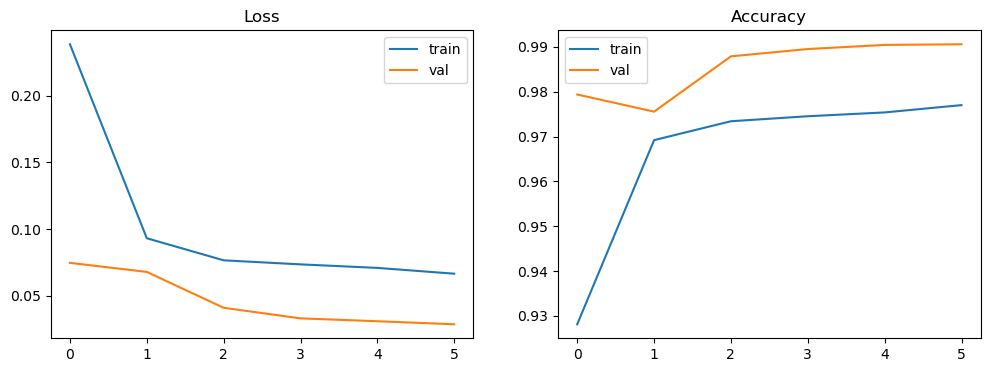

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print('Validation accuracy:', val_acc)


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.title('Loss')


plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.title('Accuracy')
plt.show()


from sklearn.metrics import classification_report


y_true, y_pred = [], []
for x, y in val_ds:
    preds = model.predict(x)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))


print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
model.save("mobilenet_fruits_model.keras")

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm


# 1. Configuración

MODEL_PATH = "mobilenet_fruits_model.keras"
UNLABELED_DIR = Path(r"C:\Users\patka\Downloads\Frutas no etiquetadas")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# IMPORTANTE: MISMO ORDEN que en entrenamiento
CLASS_NAMES = [
    'Apple', 'Banana', 'Carambola', 'Guava', 'Kiwi',
    'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon',
    'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'muskmelon'
]


In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)
print("Modelo MobileNetV2 cargado correctamente")

Modelo MobileNetV2 cargado correctamente


In [ ]:
image_paths = sorted([
    p for p in UNLABELED_DIR.iterdir()
    if p.suffix.lower() in ['.jpg', '.jpeg', '.png']
])

print("Imágenes detectadas:", len(image_paths))

def load_image(path):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img

images = []
image_ids = []

for p in image_paths:
    images.append(load_image(p))
    image_ids.append(p.name)

images = tf.stack(images)

Imágenes detectadas: 5


In [ ]:
preds = model.predict(images, batch_size=BATCH_SIZE)
pred_labels = np.argmax(preds, axis=1)
pred_names = [CLASS_NAMES[i] for i in pred_labels]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
df = pd.DataFrame({
    "image_id": image_ids,
    "predicted_label": pred_names
})

df.to_csv("predicciones_mobilenet.csv", index=False)

print("\nArchivo predicciones_mobilenet.csv creado con",
      len(df), "filas")


Archivo predicciones_mobilenet.csv creado con 5 filas
